# DAG-accumulated distance vs. true log-Euclidean distance

Spindle's block-DAG search accumulates, layer by layer, the distance from the query's
per-block matrix log to each visited node's **cluster-mean** log (radius-adjusted into a
valid lower bound for pruning). `benchmarks/holdout_core.py`'s Stage-2 re-ranking then
throws that accumulated distance away and recomputes the *exact* log-Euclidean (LE)
distance to every Stage-1 candidate's actual matrix before picking a winner.

This notebook asks: for queries where Stage-1 search actually reaches the leaf containing
the true nearest neighbour, how does the DAG's own accumulated distance relate to the
**true** distance between query and that same matched matrix? "True" is ambiguous in this
codebase in exactly the way that motivated this notebook, so both existing definitions are
compared:

- **block-diagonal true LE** ­— `benchmarks/holdout_core.compute_ground_truth`: sum of
  per-block Frobenius norms in log space (what the DAG structure itself is built around).
- **dense true LE** — `benchmarks/holdout_core.compute_ground_truth_whole_matrix`: LE
  distance on the full gene x gene matrix, ignoring block structure entirely.

No library code is modified. Everything below reuses `benchmarks.build_indexes` and
`benchmarks.holdout_core` as-is; only the final Stage-1 instrumentation (which keeps each
returned path's accumulated distance instead of discarding it) is new, and lives entirely
in this notebook.


In [1]:

import os
for _v in ("OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ.setdefault(_v, "4")

import sys
import time
from pathlib import Path

PROJECT_ROOT = Path("/home/NAShome/sarkah1/accre_transfer/data/sarkar_lab/Projects/spindle_dev")
for p in (PROJECT_ROOT / "src", PROJECT_ROOT, PROJECT_ROOT / "benchmarks"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
%matplotlib inline

import benchmarks.build_indexes as bidx
import benchmarks.holdout_core as hc
import spindle_dev.search as search

print("Imports OK.")


Imports OK.


## 1. Build a small held-out index (kidney dataset, production settings)

Smallest of the 8 Xenium sections (97,560 cells / 377 genes -> a few hundred quadtree
tiles), so a full production-config build (seed 73, 100 held-out tiles, resolution 0.2)
finishes in well under a minute on CPU -- confirmed by the existing
`xenium_human_kidney_nondiseased_index/index_stats.txt` build log (~29s for the comparable
`examples/run_single_dataset.py` config). Runs directly on the login node; no `sbatch` needed.


In [2]:

DATASET_PATH = Path("/home/NAShome/sarkah1/shared_data/insitupy_demo_data_xenium/xenium_human_kidney_nondiseased.h5ad")
SEED = 73
N_HOLDOUT = 100
TRAIN_TEST_RATIO = 0.05
RESOLUTION = 0.2
MIN_FINAL_SIZE = 15
MAX_NICHE_SIZE = 1000
BUDGET_MULTIPLIER = 2.0   # same default as benchmarks.holdout_core.perform_search

t0 = time.time()
adata, genes_work, train_tiles, train_tile_covs, test_tiles, test_tile_covs, train_idx, test_idx = bidx.load_and_split_data(
    DATASET_PATH, test_ratio=TRAIN_TEST_RATIO, seed=SEED, n_holdout=N_HOLDOUT,
)
data, out_dict = bidx.run_index(
    train_tiles, train_tile_covs, genes_work, adata,
    resolution=RESOLUTION, min_final_size=MIN_FINAL_SIZE, max_niche_size=MAX_NICHE_SIZE,
)
dag_dict, config = bidx.configure_and_build_dag(data)
build_time_s = time.time() - t0

# DAG node metadata.members stores spd_id in the ORIGINAL (pre-holdout-split) tile
# numbering (same as benchmarks.holdout_core.evaluate_against_ground_truth's
# global_to_local_train_map), while compute_ground_truth's dist_dict / niche_train_cache
# and data.labels are indexed by LOCAL position within train_tile_covs. Translate once
# here rather than re-deriving this in every cell that touches DAG member ids.
global_to_local_train_map = {int(global_id): local_idx for local_idx, global_id in enumerate(train_idx)}

print(f"Index built in {build_time_s:.1f}s")
print(f"{len(train_tiles)} train tiles indexed, {len(test_tiles)} held-out query tiles, {len(dag_dict)} niches")


[2026-09-28 13:48:19,178] INFO spindle_dev.preprocessing: build_quadtree_tiles: dropping 27 low-density tile(s) (772 spot(s) total) whose density is far below typical.


Reading data from /home/NAShome/sarkah1/shared_data/insitupy_demo_data_xenium/xenium_human_kidney_nondiseased.h5ad...
Preparing data for indexing...


[2026-09-28 13:48:19,642] INFO spindle_dev.index: Clustering SPD-s using 'tree' distance.


[2026-09-28 13:48:19,661] INFO spindle_dev.index: Building ultrametric features from SPD matrices.


Total tiles: 783 | Training/Indexed: 683 | Held out/Testing: 100 (seed=73, n_holdout=100)


...

[2026-09-28 13:48:31,469] INFO spindle_dev.index: We will use triangle inequality to order clusters.


[2026-09-28 13:48:31,469] INFO spindle_dev.index: Step 2.2: Connect block-clusters between layers based on co-occurrence in SPDs.


[2026-09-28 13:48:31,474] INFO spindle_dev.index: Check if node global_node_id matches index in nodes list


[2026-09-28 13:48:31,474] INFO spindle_dev.index: Step 2.3: Ordering block-clusters within each layer using log-Euclidean distances.


Index built in 12.4s
683 train tiles indexed, 100 held-out query tiles, 1 niches


## 2. Exact ground truth (both notions of "true")

`compute_ground_truth` ranks every train tile within each niche's own block-diagonal
layout; `compute_ground_truth_whole_matrix` ranks every train tile using the full dense
matrix, ignoring niches/blocks entirely. Both give, per query, `true_order` /
`dist_dict` keyed by the same train-tile index (0-based into `train_tile_covs`), so a
single `true_idx` can be looked up in either.


In [3]:

t0 = time.time()
gt_block = hc.compute_ground_truth(test_tile_covs, train_tile_covs, data)
gt_whole = hc.compute_ground_truth_whole_matrix(test_tile_covs, train_tile_covs)
print(f"Ground truth computed in {time.time() - t0:.1f}s")


Pre-computing matrix logarithms for training tiles...


Computing ground truth:   0%|          | 0/100 [00:00<?, ?it/s]

Pre-computing whole-matrix logarithms for training tiles...


log_spd(train, whole-matrix):   0%|          | 0/683 [00:00<?, ?it/s]

Computing whole-matrix ground truth:   0%|          | 0/100 [00:00<?, ?it/s]

Ground truth computed in 89.0s


## 3. Instrumented Stage-1 search (true niche only, distances kept)

`benchmarks.holdout_core.perform_search` searches every niche for every query and keeps
only the matched `spd_id`s, discarding each returned path's `total_distance` entirely --
that's the exact thing Stage-2 re-ranking then has to recompute from scratch. To isolate
that discarded signal, this cell searches **only the query's true-best niche** (known from
`gt_block`, so niche-routing correctness is not conflated with the traversal-distance
question this notebook is actually about) using the same `SearchConfig` scaling
(`_niche_scale_factor`, `budget_multiplier=2.0`) as production, and for every returned
path additionally computes:

- `dag_lb_dist` — `path.total_distance`, the radius-adjusted lower bound already used
  for ranking/pruning inside `search_index`.
- `dag_path_dist` — the same path's accumulated **raw** distance-to-cluster-mean (no
  radius subtraction), recomputed here from `node.metadata.mean` since `search_index`
  computes but never returns it.


In [4]:

niche_sizes = {c: int(np.sum(data.labels == c)) for c in sorted(set(int(c) for c in data.labels))}

def _niche_search_config(cluster_id, budget_multiplier=BUDGET_MULTIPLIER, effort_multiplier=1.0):
    f = hc._niche_scale_factor(niche_sizes[cluster_id]) * effort_multiplier
    cfg = search.SearchConfig(
        max_results=None,
        debug=False,
        max_failed_starts=max(1, round(100 * f)),
        max_failed_paths=max(1, round(200 * f)),
        total_paths_limit=max(1, round(3000 * f)),
    )
    return cfg, f


def search_true_niche(q_spd, true_niche, q_blocks_log_by_niche):
    # Search only `true_niche`'s DAG, keeping each returned path's accumulated distance.
    index_handle = dag_dict[true_niche]
    epsilon = config.epsilon_dict[true_niche]
    num_blocks = len(index_handle.sorted_blocks)
    cfg, f = _niche_search_config(true_niche)
    budget = float(epsilon) * float(num_blocks) * BUDGET_MULTIPLIER * f

    perm = data.perm_list[true_niche]
    q_spd_perm = q_spd[np.ix_(perm, perm)]
    query_block_runs = data.block_dict[true_niche]

    t0 = time.perf_counter()
    results = search.search_index(index_handle, q_spd_perm, [], query_block_runs, budget, config=cfg)
    dag_time = time.perf_counter() - t0

    q_blocks_log = q_blocks_log_by_niche[true_niche]
    out_paths = []
    for path in results.paths:
        member_sets = [
            {int(sid) for sid, _ in index_handle.nodes[nid].metadata.members}
            for nid in path.node_path
        ]
        candidate_ids_global = set.intersection(*member_sets) if member_sets else set()
        # Translate DAG member ids (global, pre-split numbering) to local positions
        # within train_tile_covs, matching compute_ground_truth's indexing.
        candidate_ids = {
            global_to_local_train_map[g] for g in candidate_ids_global if g in global_to_local_train_map
        }
        path_dist = sum(
            np.linalg.norm(q_blocks_log[layer] - index_handle.nodes[nid].metadata.mean, ord="fro")
            / np.sqrt(index_handle.nodes[nid].metadata.mean.shape[0])
            for layer, nid in enumerate(path.node_path)
        )
        out_paths.append({
            "candidate_ids": candidate_ids,
            "dag_lb_dist": path.total_distance,
            "dag_path_dist": path_dist,
        })
    return out_paths, dag_time, budget


records = []
query_paths = {}  # q_i -> out_paths, kept for the Part B rank-correlation analysis

for q_i in range(len(test_tile_covs)):
    per_q = gt_block["per_query"][q_i]
    true_niche = per_q["true_best_niche"]
    true_order = per_q["true_order"]
    if true_niche is None or true_niche not in dag_dict or not true_order:
        continue
    true_idx = true_order[0]

    raw = test_tile_covs[q_i]
    q_spd = raw if not isinstance(raw, dict) else raw.get("cov", raw.get("matrix", raw))

    out_paths, dag_time, budget = search_true_niche(q_spd, true_niche, per_q["query_blocks_log_by_niche"])
    query_paths[q_i] = (true_niche, out_paths)

    matched_path = next((p for p in out_paths if true_idx in p["candidate_ids"]), None)
    n_candidates = sum(len(p["candidate_ids"]) for p in out_paths)

    records.append({
        "query_idx": q_i,
        "true_niche": true_niche,
        "true_idx": true_idx,
        "found_true_match": matched_path is not None,
        "n_returned_paths": len(out_paths),
        "n_returned_candidates": n_candidates,
        "dag_lb_dist": matched_path["dag_lb_dist"] if matched_path else np.nan,
        "dag_path_dist": matched_path["dag_path_dist"] if matched_path else np.nan,
        "block_true_dist": gt_block["per_query"][q_i]["dist_dict"][true_idx],
        "dense_true_dist": gt_whole["per_query"][q_i]["dist_dict"][true_idx],
        "dag_time_s": dag_time,
        "budget": budget,
    })

df = pd.DataFrame(records)
out_csv = PROJECT_ROOT / "HS_notebooks" / "dag_vs_true_le_results.csv"
df.to_csv(out_csv, index=False)

match_rate = df["found_true_match"].mean()
print(f"{len(df)} queries with a valid true-niche ground truth")
print(f"True match recovered by Stage-1 search (true-niche only): {df['found_true_match'].sum()} / {len(df)} ({match_rate:.1%})")
df.head()


100 queries with a valid true-niche ground truth
True match recovered by Stage-1 search (true-niche only): 100 / 100 (100.0%)


,query_idx,true_niche,true_idx,found_true_match,n_returned_paths,n_returned_candidates,dag_lb_dist,dag_path_dist,block_true_dist,dense_true_dist,dag_time_s,budget
0,0,0,370,True,683,683,4.305436,54.168076,55.087076,6.262568,0.290427,287.4574
1,1,0,513,True,683,683,7.041099,73.668831,70.863160,6.185087,0.287913,287.4574
2,2,0,466,True,683,683,9.214987,72.204736,69.370799,6.185585,0.295061,287.4574
3,3,0,297,True,683,683,8.158939,75.565093,67.620968,5.979619,0.285203,287.4574
4,4,0,217,True,683,683,3.919191,56.968483,54.466108,6.232505,0.282844,287.4574


## 4. Part A: DAG-accumulated distance vs. exact true distance

Restricted to queries where Stage-1 search actually recovered the leaf containing the true
match (`found_true_match`). For those, `dag_lb_dist` / `dag_path_dist` are the DAG's own
accumulated distance to that leaf's *cluster mean* at each level; `block_true_dist` /
`dense_true_dist` are the *exact* distance to the true match's own matrix, under each of
the two definitions of "true."


In [5]:

matched = df[df["found_true_match"]].copy()
print(f"n = {len(matched)} matched queries")

def _report(a, b, name_a, name_b):
    pear = stats.pearsonr(a, b)
    spear = stats.spearmanr(a, b)
    ratio = a / b.replace(0, np.nan)
    print(f"{name_a} vs {name_b}: pearson r={pear.statistic:.3f} (p={pear.pvalue:.1e}), "
          f"spearman rho={spear.statistic:.3f} (p={spear.pvalue:.1e}), "
          f"mean ratio={ratio.mean():.3f}, median ratio={ratio.median():.3f}")

_report(matched["dag_lb_dist"], matched["block_true_dist"], "dag_lb_dist", "block_true_dist")
_report(matched["dag_path_dist"], matched["block_true_dist"], "dag_path_dist", "block_true_dist")
_report(matched["dag_lb_dist"], matched["dense_true_dist"], "dag_lb_dist", "dense_true_dist")
_report(matched["block_true_dist"], matched["dense_true_dist"], "block_true_dist", "dense_true_dist")


n = 100 matched queries
dag_lb_dist vs block_true_dist: pearson r=0.801 (p=1.5e-23), spearman rho=0.817 (p=4.1e-25), mean ratio=0.144, median ratio=0.128
dag_path_dist vs block_true_dist: pearson r=0.967 (p=6.4e-60), spearman rho=0.955 (p=9.2e-54), mean ratio=1.076, median ratio=1.074
dag_lb_dist vs dense_true_dist: pearson r=-0.315 (p=1.4e-03), spearman rho=-0.216 (p=3.1e-02), mean ratio=1.695, median ratio=1.425
block_true_dist vs dense_true_dist: pearson r=-0.247 (p=1.3e-02), spearman rho=-0.236 (p=1.8e-02), mean ratio=10.975, median ratio=10.520


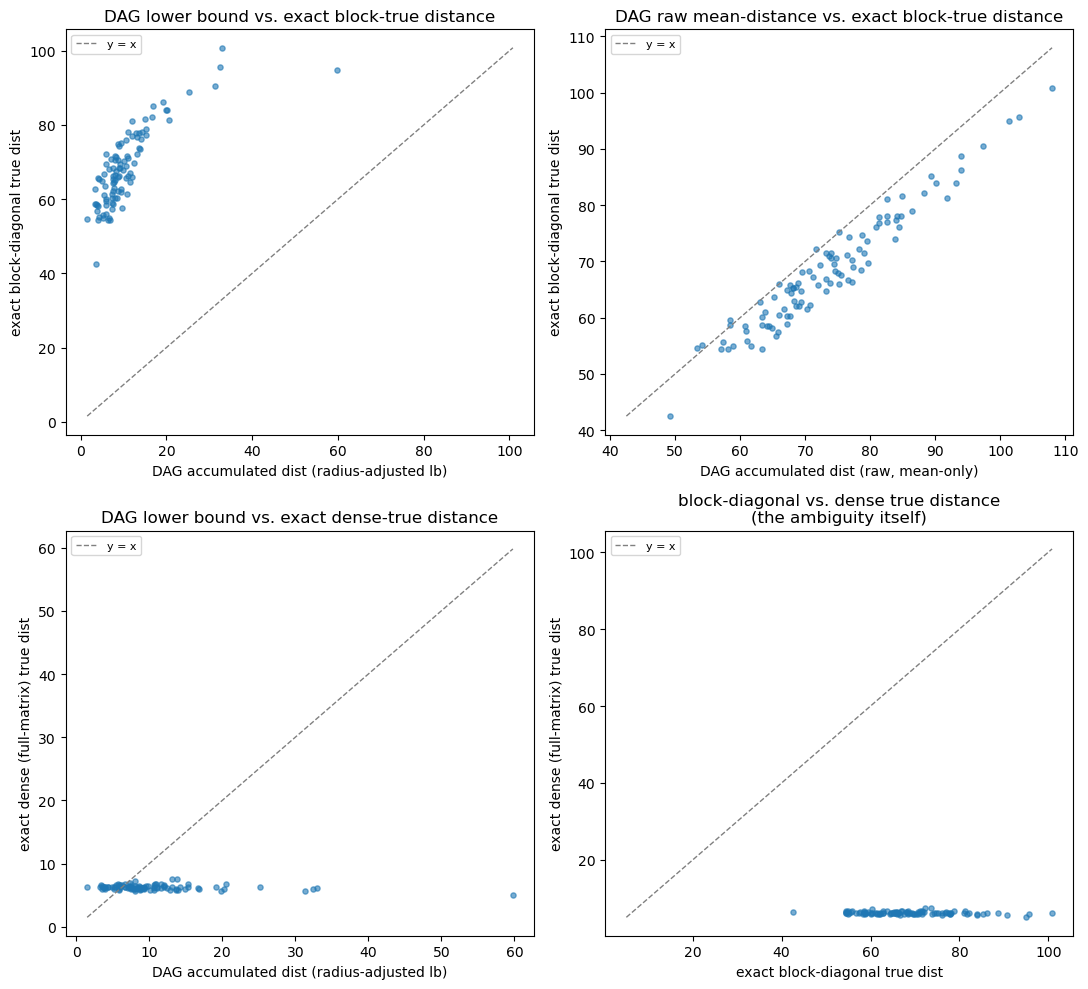

In [6]:

fig, axes = plt.subplots(2, 2, figsize=(11, 10))

def _scatter(ax, x, y, xlabel, ylabel):
    ax.scatter(x, y, s=14, alpha=0.6)
    lo = min(x.min(), y.min())
    hi = max(x.max(), y.max())
    ax.plot([lo, hi], [lo, hi], color="gray", linestyle="--", linewidth=1, label="y = x")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)

_scatter(axes[0, 0], matched["dag_lb_dist"], matched["block_true_dist"],
          "DAG accumulated dist (radius-adjusted lb)", "exact block-diagonal true dist")
axes[0, 0].set_title("DAG lower bound vs. exact block-true distance")

_scatter(axes[0, 1], matched["dag_path_dist"], matched["block_true_dist"],
          "DAG accumulated dist (raw, mean-only)", "exact block-diagonal true dist")
axes[0, 1].set_title("DAG raw mean-distance vs. exact block-true distance")

_scatter(axes[1, 0], matched["dag_lb_dist"], matched["dense_true_dist"],
          "DAG accumulated dist (radius-adjusted lb)", "exact dense (full-matrix) true dist")
axes[1, 0].set_title("DAG lower bound vs. exact dense-true distance")

_scatter(axes[1, 1], matched["block_true_dist"], matched["dense_true_dist"],
          "exact block-diagonal true dist", "exact dense (full-matrix) true dist")
axes[1, 1].set_title("block-diagonal vs. dense true distance\n(the ambiguity itself)")

fig.tight_layout()
plt.show()


## 5. Part B (bonus): does Stage-2 re-ranking actually change the winner?

Same true-niche candidate pool Stage-1 already returned (`query_paths`), but now every
individual candidate's **exact** block-diagonal distance is looked up from
`gt_block["niche_train_cache"]` (already-cached matrix logs, so this is a cheap norm, not
a fresh eigendecomposition -- exactly what Stage-2 re-ranking pays for). Each candidate's
`dag_lb_dist` is the accumulated distance of whichever path (i.e. leaf/cluster) contains
it. This compares, within the *same* retrieved pool: ranking candidates by the DAG's own
free accumulated distance (no re-ranking) vs. Stage-2's paid exact re-ranking.


In [7]:

niche_train_cache = gt_block["niche_train_cache"]

rank_records = []
for q_i, (true_niche, out_paths) in query_paths.items():
    n_candidates = sum(len(p["candidate_ids"]) for p in out_paths)
    if n_candidates < 3:
        continue

    q_blocks_log = gt_block["per_query"][q_i]["query_blocks_log_by_niche"][true_niche]
    block_runs = data.block_dict[true_niche]
    _, cached_logs = niche_train_cache[true_niche]

    cand_dag_dist, cand_exact_dist = [], []
    for p in out_paths:
        for cid in p["candidate_ids"]:
            t_logs = cached_logs[cid]
            exact_d = sum(
                np.linalg.norm(q_blocks_log[b] - t_logs[b], ord="fro") / np.sqrt(e - s)
                for b, (s, e) in enumerate(block_runs)
            )
            cand_dag_dist.append(p["dag_lb_dist"])
            cand_exact_dist.append(exact_d)

    tau = stats.kendalltau(cand_dag_dist, cand_exact_dist).statistic
    top1_dag = np.argmin(cand_dag_dist)
    top1_exact = np.argmin(cand_exact_dist)
    rank_records.append({
        "query_idx": q_i,
        "n_candidates": n_candidates,
        "kendall_tau": tau,
        "top1_agrees": bool(top1_dag == top1_exact),
    })

rank_df = pd.DataFrame(rank_records)
print(f"n = {len(rank_df)} queries with >= 3 Stage-1 candidates in the true niche")
print(f"Mean Kendall tau (DAG accumulated dist vs. exact re-rank dist): {rank_df['kendall_tau'].mean():.3f}")
print(f"Top-1 pick agrees between DAG-only ranking and Stage-2 exact re-rank: "
      f"{rank_df['top1_agrees'].sum()} / {len(rank_df)} ({rank_df['top1_agrees'].mean():.1%})")
rank_df.describe()


n = 100 queries with >= 3 Stage-1 candidates in the true niche
Mean Kendall tau (DAG accumulated dist vs. exact re-rank dist): 0.629
Top-1 pick agrees between DAG-only ranking and Stage-2 exact re-rank: 5 / 100 (5.0%)


,query_idx,n_candidates,kendall_tau
count,100.000000,100.0,100.000000
mean,49.500000,683.0,0.629456
std,29.011492,0.0,0.102496
min,0.000000,683.0,0.322173
25%,24.750000,683.0,0.567492
50%,49.500000,683.0,0.656625
75%,74.250000,683.0,0.701560
max,99.000000,683.0,0.799771


## 6. Part C: ranking by the raw DAG distance instead

`dag_lb_dist` (Part B) is `search_index`'s radius-adjusted lower bound -- valid for
pruning, but, as the earlier scatter plots show, it subtracts each layer's cluster radius
and compounds into a large, systematic underestimate of the true distance over an 18-block
path. `dag_path_dist` is the same accumulated distance-to-cluster-mean *without* that
subtraction -- already computed for every returned path in `search_true_niche` (Part 3)
and discarded there just like `search_index` discards it internally. It tracked
`block_true_dist` almost 1:1 in Part A (pearson r=0.97, vs. 0.80 for `dag_lb_dist`).

This repeats Part B's comparison -- DAG-only ranking (free) vs. Stage-2's exact re-rank
(paid) -- on the exact same Stage-1 candidate pools, but ranking by `dag_path_dist` instead
of `dag_lb_dist`, to see whether the better point-estimate also makes it a better
*ranking* signal, i.e. whether it could stand in for Stage-2's exact re-rank.


In [8]:

rank_records_v2 = []
for q_i, (true_niche, out_paths) in query_paths.items():
    n_candidates = sum(len(p["candidate_ids"]) for p in out_paths)
    if n_candidates < 3:
        continue

    q_blocks_log = gt_block["per_query"][q_i]["query_blocks_log_by_niche"][true_niche]
    block_runs = data.block_dict[true_niche]
    _, cached_logs = niche_train_cache[true_niche]

    cand_lb_dist, cand_path_dist, cand_exact_dist = [], [], []
    for p in out_paths:
        for cid in p["candidate_ids"]:
            t_logs = cached_logs[cid]
            exact_d = sum(
                np.linalg.norm(q_blocks_log[b] - t_logs[b], ord="fro") / np.sqrt(e - s)
                for b, (s, e) in enumerate(block_runs)
            )
            cand_lb_dist.append(p["dag_lb_dist"])
            cand_path_dist.append(p["dag_path_dist"])
            cand_exact_dist.append(exact_d)

    tau_lb = stats.kendalltau(cand_lb_dist, cand_exact_dist).statistic
    tau_path = stats.kendalltau(cand_path_dist, cand_exact_dist).statistic
    top1_exact = int(np.argmin(cand_exact_dist))
    top1_lb = int(np.argmin(cand_lb_dist))
    top1_path = int(np.argmin(cand_path_dist))

    rank_records_v2.append({
        "query_idx": q_i,
        "n_candidates": n_candidates,
        "kendall_tau_lb": tau_lb,
        "kendall_tau_path": tau_path,
        "top1_lb_agrees_exact": top1_lb == top1_exact,
        "top1_path_agrees_exact": top1_path == top1_exact,
        "top1_lb_agrees_path": top1_lb == top1_path,
    })

rank_df2 = pd.DataFrame(rank_records_v2)
out_csv2 = PROJECT_ROOT / "HS_notebooks" / "dag_path_vs_lb_rerank_results.csv"
rank_df2.to_csv(out_csv2, index=False)

print(f"n = {len(rank_df2)} queries")
print(f"Mean Kendall tau -- lb-ranked  vs. exact re-rank: {rank_df2['kendall_tau_lb'].mean():.3f}")
print(f"Mean Kendall tau -- DAG_path-ranked vs. exact re-rank: {rank_df2['kendall_tau_path'].mean():.3f}")
print(f"Top-1 agreement -- lb  vs. exact: {rank_df2['top1_lb_agrees_exact'].mean():.1%}")
print(f"Top-1 agreement -- DAG_path vs. exact: {rank_df2['top1_path_agrees_exact'].mean():.1%}")
print(f"Top-1 agreement -- lb  vs. DAG_path (do the two DAG-only signals even agree with "
      f"each other, no ground truth involved): {rank_df2['top1_lb_agrees_path'].mean():.1%}")
rank_df2.describe()


n = 100 queries
Mean Kendall tau -- lb-ranked  vs. exact re-rank: 0.629
Mean Kendall tau -- DAG_path-ranked vs. exact re-rank: 0.660
Top-1 agreement -- lb  vs. exact: 5.0%
Top-1 agreement -- DAG_path vs. exact: 5.0%
Top-1 agreement -- lb  vs. DAG_path (do the two DAG-only signals even agree with each other, no ground truth involved): 50.0%


,query_idx,n_candidates,kendall_tau_lb,kendall_tau_path
count,100.000000,100.0,100.000000,100.000000
mean,49.500000,683.0,0.629456,0.660025
std,29.011492,0.0,0.102496,0.095405
min,0.000000,683.0,0.322173,0.453352
25%,24.750000,683.0,0.567492,0.597047
50%,49.500000,683.0,0.656625,0.680773
75%,74.250000,683.0,0.701560,0.733593
max,99.000000,683.0,0.799771,0.827044


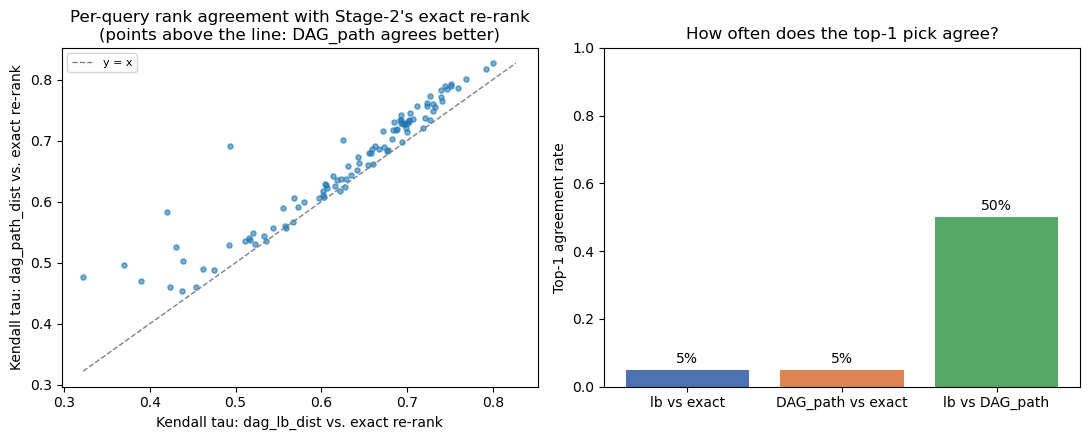

In [9]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].scatter(rank_df2["kendall_tau_lb"], rank_df2["kendall_tau_path"], s=14, alpha=0.6)
lo = min(rank_df2["kendall_tau_lb"].min(), rank_df2["kendall_tau_path"].min())
hi = max(rank_df2["kendall_tau_lb"].max(), rank_df2["kendall_tau_path"].max())
axes[0].plot([lo, hi], [lo, hi], color="gray", linestyle="--", linewidth=1, label="y = x")
axes[0].set_xlabel("Kendall tau: dag_lb_dist vs. exact re-rank")
axes[0].set_ylabel("Kendall tau: dag_path_dist vs. exact re-rank")
axes[0].set_title("Per-query rank agreement with Stage-2's exact re-rank\n(points above the line: DAG_path agrees better)")
axes[0].legend(fontsize=8)

rates = pd.Series({
    "lb vs exact": rank_df2["top1_lb_agrees_exact"].mean(),
    "DAG_path vs exact": rank_df2["top1_path_agrees_exact"].mean(),
    "lb vs DAG_path": rank_df2["top1_lb_agrees_path"].mean(),
})
axes[1].bar(rates.index, rates.values, color=["#4C72B0", "#DD8452", "#55A868"])
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("Top-1 agreement rate")
axes[1].set_title("How often does the top-1 pick agree?")
for i, v in enumerate(rates.values):
    axes[1].text(i, v + 0.02, f"{v:.0%}", ha="center")

fig.tight_layout()
plt.show()


## 7. Part D: Recall@K / Overlap@K curves (K = 1..100)

Exact top-1 agreement is a harsh test here -- each query's pool has all 683 training tiles
in it (this run's single-niche, effectively-unpruned search), so "pick the single best out
of 683 near-ties" is a stringent bar for any cheap proxy. Sweeping K instead of fixing it
at 1 or 10 shows how quickly that gap closes as the shortlist grows:

- **Recall@K** -- is the true single best match inside the DAG-ranked top K?
- **Overlap@K** -- how much does the DAG-ranked top K itself overlap with the *exact*
  top K (Jaccard-style: `|DAG top-K ∩ exact top-K| / K`)?

Both computed for `dag_lb_dist` (current, radius-adjusted) and `dag_path_dist` (no radius
subtraction), plus `lb` vs `raw` against each other (no ground truth involved), at
K = 1, 5, 10, 20, 30, ..., 100.


In [10]:

K_LIST = [1, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

curve_records = []
for q_i, (true_niche, out_paths) in query_paths.items():
    q_blocks_log = gt_block["per_query"][q_i]["query_blocks_log_by_niche"][true_niche]
    block_runs = data.block_dict[true_niche]
    _, cached_logs = niche_train_cache[true_niche]

    cids, lb_d, path_d, exact_d = [], [], [], []
    for p in out_paths:
        for cid in p["candidate_ids"]:
            t_logs = cached_logs[cid]
            e_d = sum(
                np.linalg.norm(q_blocks_log[b] - t_logs[b], ord="fro") / np.sqrt(e - s)
                for b, (s, e) in enumerate(block_runs)
            )
            cids.append(cid)
            lb_d.append(p["dag_lb_dist"])
            path_d.append(p["dag_path_dist"])
            exact_d.append(e_d)

    n_candidates = len(cids)
    if n_candidates < max(K_LIST):
        # skip queries too small to evaluate every K on the same footing
        continue

    cids = np.array(cids)
    full_order_lb = cids[np.argsort(lb_d)]
    full_order_path = cids[np.argsort(path_d)]
    full_order_exact = cids[np.argsort(exact_d)]
    exact_top1 = full_order_exact[0]

    for K in K_LIST:
        set_exact = set(full_order_exact[:K])
        set_lb = set(full_order_lb[:K])
        set_path = set(full_order_path[:K])
        curve_records.append({
            "query_idx": q_i,
            "K": K,
            "recall_lb": exact_top1 in set_lb,
            "recall_path": exact_top1 in set_path,
            "overlap_lb": len(set_lb & set_exact) / K,
            "overlap_path": len(set_path & set_exact) / K,
            "overlap_lb_vs_path": len(set_lb & set_path) / K,
        })

curve_df = pd.DataFrame(curve_records)
out_csv3 = PROJECT_ROOT / "HS_notebooks" / "dag_topk_curve_results.csv"
curve_df.to_csv(out_csv3, index=False)

curve_summary = curve_df.groupby("K")[
    ["recall_lb", "recall_path", "overlap_lb", "overlap_path", "overlap_lb_vs_path"]
].mean()
print(f"n = {curve_df['query_idx'].nunique()} queries evaluated at every K in {K_LIST}")
curve_summary


n = 100 queries evaluated at every K in [1, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]


,recall_lb,recall_path,overlap_lb,overlap_path,overlap_lb_vs_path
K,,,,,
1,0.05,0.05,0.050000,0.050000,0.500000
5,0.21,0.30,0.148000,0.184000,0.616000
10,0.29,0.41,0.198000,0.241000,0.655000
20,0.48,0.55,0.270500,0.300000,0.687500
30,0.57,0.61,0.315667,0.360667,0.708333
40,0.65,0.67,0.358750,0.407750,0.725000
50,0.70,0.74,0.394200,0.438400,0.748600
60,0.73,0.81,0.416667,0.465000,0.760167
70,0.76,0.83,0.439571,0.485286,0.765143


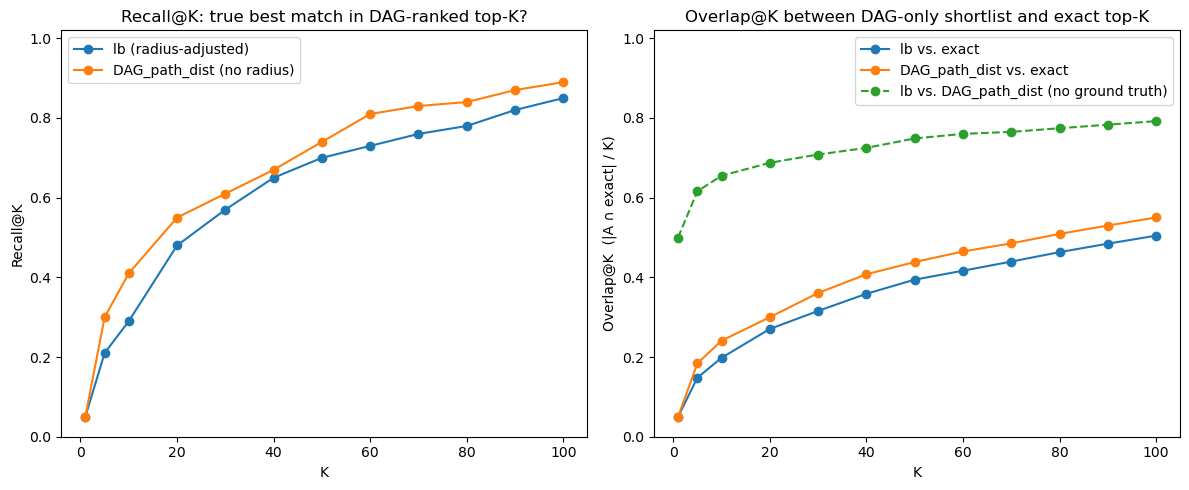

In [11]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(curve_summary.index, curve_summary["recall_lb"], marker="o", label="lb (radius-adjusted)")
axes[0].plot(curve_summary.index, curve_summary["recall_path"], marker="o", label="DAG_path_dist (no radius)")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Recall@K")
axes[0].set_title("Recall@K: true best match in DAG-ranked top-K?")
axes[0].set_ylim(0, 1.02)
axes[0].legend()

axes[1].plot(curve_summary.index, curve_summary["overlap_lb"], marker="o", label="lb vs. exact")
axes[1].plot(curve_summary.index, curve_summary["overlap_path"], marker="o", label="DAG_path_dist vs. exact")
axes[1].plot(curve_summary.index, curve_summary["overlap_lb_vs_path"], marker="o", linestyle="--",
             label="lb vs. DAG_path_dist (no ground truth)")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Overlap@K  (|A ∩ exact| / K)")
axes[1].set_title("Overlap@K between DAG-only shortlist and exact top-K")
axes[1].set_ylim(0, 1.02)
axes[1].legend()

fig.tight_layout()
plt.show()


## 8. Part E: recovering the *global* true block-NN vs. the *global* true dense-NN,
ranking by `dag_path_dist` alone

Part D's "exact" target was the best match *within whatever Stage-1 already returned* --
useful for isolating the ranking question, but it silently assumes Stage-1's pool always
contains the real answer. This section uses the two *global* ground truths instead
(`compute_ground_truth` / `compute_ground_truth_whole_matrix`, computed once in section 2
over every training tile, not just the retrieved pool):

- `true_block_idx` -- the actual block-diagonal nearest neighbour, dataset-wide.
- `true_dense_idx` -- the actual dense (whole-matrix) nearest neighbour, dataset-wide.
  Part A already showed block-true and dense-true distances for the *same* pair are
  essentially uncorrelated, so these two are frequently different tiles.

Since the lower bound (`dag_lb_dist`) is going to be dropped as the ranking signal (only
`dag_path_dist` will actually be used to rank), this section ranks the Stage-1 candidate
pool by `dag_path_dist` alone and asks, at each K: is `true_block_idx` in the top-K? Is
`true_dense_idx` in the top-K? `dag_path_dist` is computed purely from block-diagonal
quantities (query vs. cluster-mean, block by block), so a priori there's no reason to
expect it to be a good ranking signal for the dense target at all -- this checks that
directly rather than assuming it.


In [12]:

block_dense_curve_records = []
coverage_records = []

for q_i, (true_niche, out_paths) in query_paths.items():
    true_block_idx = gt_block["per_query"][q_i]["true_order"][0]
    true_dense_idx = gt_whole["per_query"][q_i]["true_order"][0]

    cids, path_d = [], []
    for p in out_paths:
        for cid in p["candidate_ids"]:
            cids.append(cid)
            path_d.append(p["dag_path_dist"])

    n_candidates = len(cids)
    cids = np.array(cids)
    pool = set(cids.tolist())

    coverage_records.append({
        "query_idx": q_i,
        "same_target": bool(true_block_idx == true_dense_idx),
        "block_target_in_pool": true_block_idx in pool,
        "dense_target_in_pool": true_dense_idx in pool,
    })

    if n_candidates < max(K_LIST):
        continue

    full_order_path = cids[np.argsort(path_d)]
    for K in K_LIST:
        set_path = set(full_order_path[:K])
        block_dense_curve_records.append({
            "query_idx": q_i,
            "K": K,
            "recall_block_target": true_block_idx in set_path,
            "recall_dense_target": true_dense_idx in set_path,
        })

coverage_df = pd.DataFrame(coverage_records)
print(f"n = {len(coverage_df)} queries")
print(f"Block-true and dense-true target are the SAME tile: {coverage_df['same_target'].mean():.1%}")
print(f"Global block-true target ever inside the Stage-1 pool: {coverage_df['block_target_in_pool'].mean():.1%}")
print(f"Global dense-true target ever inside the Stage-1 pool: {coverage_df['dense_target_in_pool'].mean():.1%}")

block_dense_curve_df = pd.DataFrame(block_dense_curve_records)
out_csv4 = PROJECT_ROOT / "HS_notebooks" / "dag_path_dist_block_vs_dense_recall.csv"
block_dense_curve_df.to_csv(out_csv4, index=False)

block_dense_summary = block_dense_curve_df.groupby("K")[["recall_block_target", "recall_dense_target"]].mean()
print(f"\nn = {block_dense_curve_df['query_idx'].nunique()} queries evaluated at every K in {K_LIST}")
block_dense_summary


n = 100 queries
Block-true and dense-true target are the SAME tile: 0.0%
Global block-true target ever inside the Stage-1 pool: 100.0%
Global dense-true target ever inside the Stage-1 pool: 100.0%

n = 100 queries evaluated at every K in [1, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]


,recall_block_target,recall_dense_target
K,,
1,0.05,0.01
5,0.30,0.02
10,0.41,0.02
20,0.55,0.03
30,0.61,0.03
40,0.67,0.04
50,0.74,0.04
60,0.81,0.04
70,0.83,0.05


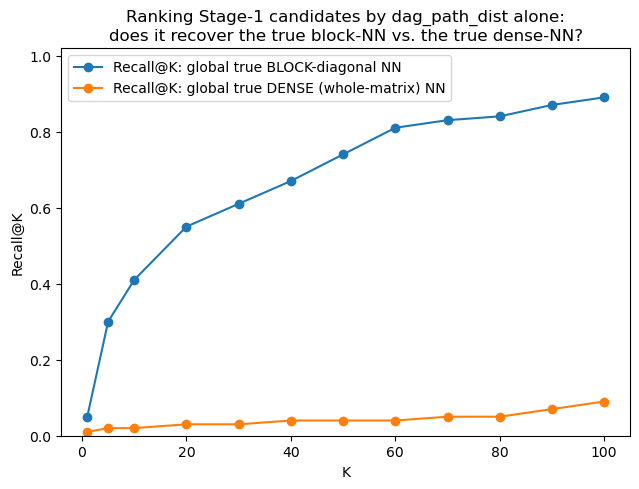

In [13]:

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.plot(block_dense_summary.index, block_dense_summary["recall_block_target"], marker="o",
        label="Recall@K: global true BLOCK-diagonal NN")
ax.plot(block_dense_summary.index, block_dense_summary["recall_dense_target"], marker="o",
        label="Recall@K: global true DENSE (whole-matrix) NN")
ax.set_xlabel("K")
ax.set_ylabel("Recall@K")
ax.set_title("Ranking Stage-1 candidates by dag_path_dist alone:\ndoes it recover the true block-NN vs. the true dense-NN?")
ax.set_ylim(0, 1.02)
ax.legend()
fig.tight_layout()
plt.show()
